In [1]:
import numpy as np
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools


In [2]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver() 
    print('Running on TPU', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy()

print("REPLICAS:", strategy.num_replicas_in_sync)


REPLICAS: 1


In [3]:
data_paths = {
    'Bearing Fault': r'E:\Cutting Tool Paper\Dataset\cutting tool data\new_data\CWT\Bearing Fault Data',
    'Gear Fault': r'E:\Cutting Tool Paper\Dataset\cutting tool data\new_data\CWT\Gear Fault Data',
    'Tool Fault': r'E:\Cutting Tool Paper\Dataset\cutting tool data\new_data\CWT\Tool Fault Data',
    'Normal': r'E:\Cutting Tool Paper\Dataset\cutting tool data\new_data\CWT\Normal Data'
}

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16 * strategy.num_replicas_in_sync

def load_images_from_folder(folder, label, image_size):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img = load_img(os.path.join(folder, filename), target_size=image_size)
        if img is not None:
            images.append(img_to_array(img) / 255.0)  # Ensure normalization
            labels.append(label)
    return images, labels

def load_dataset(data_paths, image_size):
    images = []
    labels = []
    for label, path in enumerate(data_paths.values()):
        class_images, class_labels = load_images_from_folder(path, label, image_size)
        images.extend(class_images)
        labels.extend(class_labels)
    return np.array(images), np.array(labels)

# Load datasets
X, y = load_dataset(data_paths, IMAGE_SIZE)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
with strategy.scope():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMAGE_SIZE + (3,)),  # Increased filters
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # Increased filters
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),  # Moderate dense layer
        tf.keras.layers.Dropout(0.5),  # Balanced dropout rate
        tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # Moderate learning rate
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )


C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode='max')

EPOCHS = 20  # Adjusted number of epochs

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.2451 - loss: 3.7357 - val_accuracy: 0.2812 - val_loss: 1.9488
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.2853 - loss: 1.8317 - val_accuracy: 0.5938 - val_loss: 1.1702
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.3402 - loss: 1.3419 - val_accuracy: 0.8125 - val_loss: 1.0918
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.5065 - loss: 1.1128 - val_accuracy: 0.5312 - val_loss: 0.9363
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.5402 - loss: 1.0665 - val_accuracy: 0.8125 - val_loss: 0.7020
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.6266 - loss: 0.7864 - val_accuracy: 0.8125 - val_loss: 0.5288


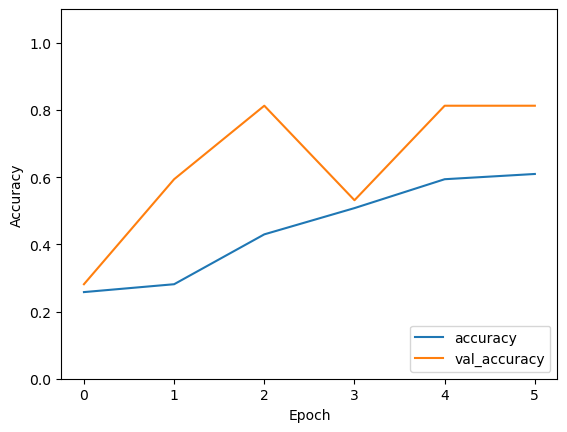

1/1 - 0s - 216ms/step - accuracy: 0.8125 - loss: 1.0918
Validation accuracy: 81.25%


In [6]:
# Plotting training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.show()

# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=2)
print(f"Validation accuracy: {val_acc * 100:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Training Data Classification Report:
                precision    recall  f1-score   support

Bearing Fault       1.00      1.00      1.00        30
   Gear Fault       0.00      0.00      0.00        34
   Tool Fault       0.48      1.00      0.65        31
       Normal       1.00      1.00      1.00        33

     accuracy                           0.73       128
    macro avg       0.62      0.75      0.66       128
 weighted avg       0.61      0.73      0.65       128



C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

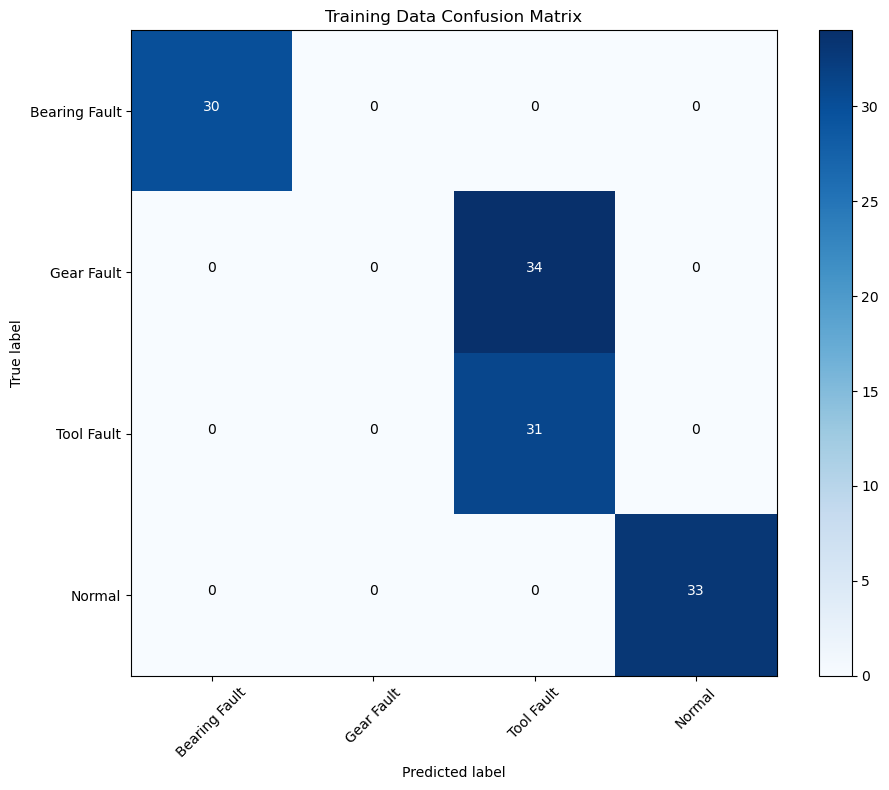

In [7]:
# Predicting the classes for training data
y_train_pred = model.predict(X_train)
y_train_pred_classes = np.argmax(y_train_pred, axis=1)

# Classification report for training data
print("Training Data Classification Report:\n", classification_report(y_train, y_train_pred_classes, target_names=list(data_paths.keys())))

# Confusion matrix for training data
train_conf_matrix = confusion_matrix(y_train, y_train_pred_classes)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = 'd'
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(train_conf_matrix, classes=list(data_paths.keys()), title='Training Data Confusion Matrix')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Classification Report:
                precision    recall  f1-score   support

Bearing Fault       1.00      1.00      1.00        10
   Gear Fault       0.00      0.00      0.00         6
   Tool Fault       0.60      1.00      0.75         9
       Normal       1.00      1.00      1.00         7

     accuracy                           0.81        32
    macro avg       0.65      0.75      0.69        32
 weighted avg       0.70      0.81      0.74        32



C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

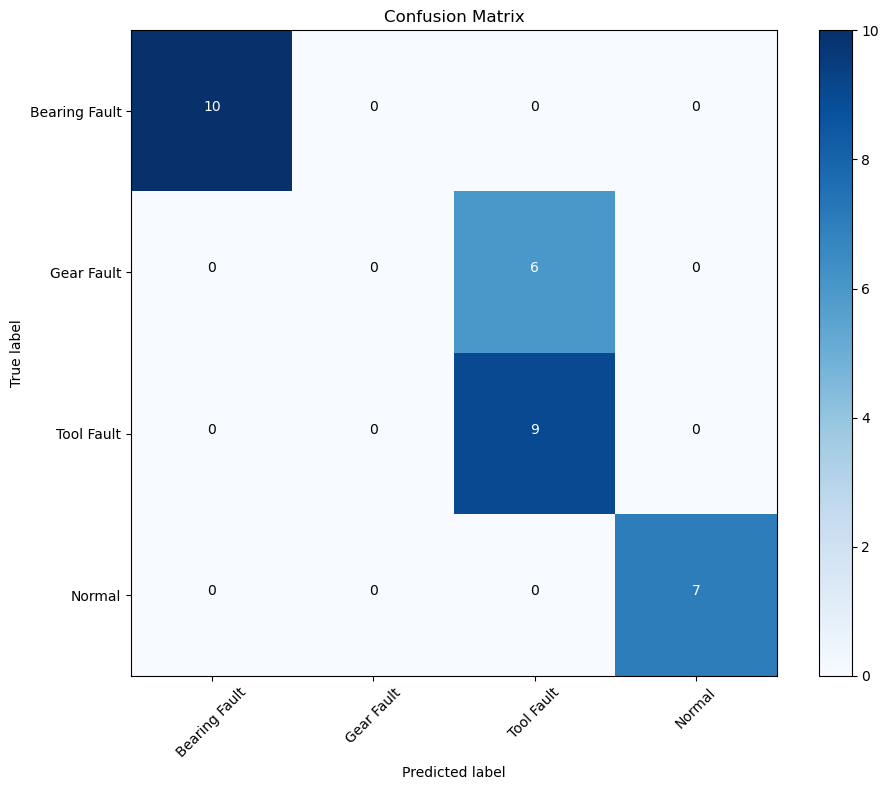

In [8]:
# Predicting the classes
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("Classification Report:\n", classification_report(y_val, y_pred_classes, target_names=list(data_paths.keys())))

# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred_classes)

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = 'd'
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(conf_matrix, classes=list(data_paths.keys()))


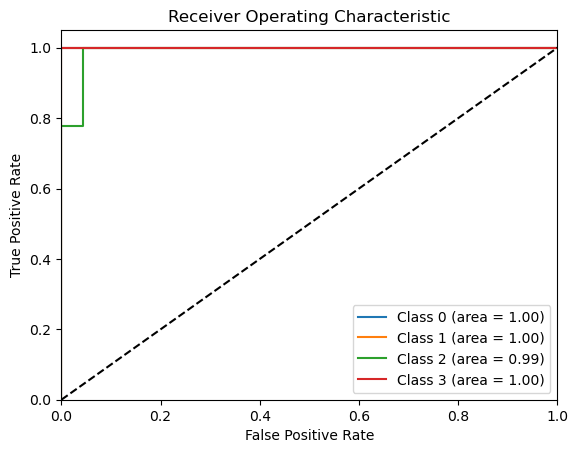

In [9]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(data_paths)):
    fpr[i], tpr[i], _ = roc_curve(y_val == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(data_paths)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
